# Weight Interpolation Analysis: BPR-only vs PG/SPO+

This notebook interpolates between model weights learned by BPR-only and PG/SPO+ methods.
At each interpolation point $\theta_\alpha = (1-\alpha)\theta_{\text{BPR}} + \alpha\,\theta_{\text{other}}$,
we compute:
- **BPR** (normalized regret / best possible ratio)
- **NLL** (negative log-likelihood)
- **PG loss** (perturbation gradient surrogate) at multiple sigma values
- **SPO+ loss** (surrogate)

If BPR decreases monotonically from $\alpha=0$ to $\alpha=1$, the BPR-only solution is genuinely
superior. If there's a non-monotonic shape, the PG/SPO+ optimizer may have gotten stuck in a local minimum.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import torch
import numpy as np
import pandas as pd
import ast
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import gaussian_kde
import glob
from torch_models import PyEPONegativeBinomialRegressionModel, deterministic_bpr

torch.manual_seed(42)
np.random.seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


## Data Loading (reused from InterpolateWeights.ipynb)

In [3]:
def load_data(data_dir, bird=False):
    """Load and process training, validation, and test data."""
    prefix = 'bird_' if bird else ''

    train_X_df = pd.read_csv(os.path.join(data_dir, f'{prefix}train_x.csv'), index_col=[0,1])
    train_Y_df = pd.read_csv(os.path.join(data_dir, f'{prefix}train_y.csv'), index_col=[0,1])
    val_X_df = pd.read_csv(os.path.join(data_dir, f'{prefix}valid_x.csv'), index_col=[0,1])
    val_Y_df = pd.read_csv(os.path.join(data_dir, f'{prefix}valid_y.csv'), index_col=[0,1])
    test_X_df = pd.read_csv(os.path.join(data_dir, f'{prefix}test_x.csv'), index_col=[0,1])
    test_Y_df = pd.read_csv(os.path.join(data_dir, f'{prefix}test_y.csv'), index_col=[0,1])

    def convert_df_to_3d_array(df):
        geoids = sorted(df.index.get_level_values('geoid').unique())
        timesteps = sorted(df.index.get_level_values('timestep').unique())
        geoid_to_idx = {geoid: idx for idx, geoid in enumerate(geoids)}
        num_timesteps = len(timesteps)
        num_locations = len(geoids)
        num_features = len(df.columns)
        X = np.zeros((num_timesteps, num_locations, num_features))
        for (geoid, timestep), row in df.iterrows():
            t_idx = timesteps.index(timestep)
            g_idx = geoid_to_idx[geoid]
            X[t_idx, g_idx, :] = row.values
        return X, geoids, timesteps

    def convert_y_df_to_2d_array(y_df, geoids, timesteps):
        num_timesteps = len(timesteps)
        num_locations = len(geoids)
        y = np.zeros((num_timesteps, num_locations))
        geoid_to_idx = {geoid: idx for idx, geoid in enumerate(geoids)}
        for (geoid, timestep), value in y_df.iloc[:, 0].items():
            t_idx = timesteps.index(timestep)
            g_idx = geoid_to_idx[geoid]
            y[t_idx, g_idx] = value
        return y

    train_X, geoids, timesteps = convert_df_to_3d_array(train_X_df)
    train_time = np.array([timesteps] * len(geoids)).T
    train_y = convert_y_df_to_2d_array(train_Y_df, geoids, timesteps)

    val_X, val_geoids, val_timesteps = convert_df_to_3d_array(val_X_df)
    val_time = np.array([val_timesteps] * len(val_geoids)).T
    val_y = convert_y_df_to_2d_array(val_Y_df, val_geoids, val_timesteps)

    test_X, test_geoids, test_timesteps = convert_df_to_3d_array(test_X_df)
    test_time = np.array([test_timesteps] * len(test_geoids)).T
    test_y = convert_y_df_to_2d_array(test_Y_df, test_geoids, test_timesteps)

    return {
        'train': (torch.tensor(train_X, dtype=torch.float32),
                  torch.tensor(train_time, dtype=torch.float32),
                  torch.tensor(train_y, dtype=torch.float32)),
        'val': (torch.tensor(val_X, dtype=torch.float32),
                torch.tensor(val_time, dtype=torch.float32),
                torch.tensor(val_y, dtype=torch.float32)),
        'test': (torch.tensor(test_X, dtype=torch.float32),
                 torch.tensor(test_time, dtype=torch.float32),
                 torch.tensor(test_y, dtype=torch.float32))
    }

## Dataset & Model Path Configuration

In [4]:
DATASET_CONFIGS = {
    'cook': {
        'data_dir': '/cluster/tufts/hugheslab/datasets/NSF_OD/cleaned/cook',
        'K': 100,
        'bird': False,
        'title': 'Cook County IL Fatal Overdoses',
        'bpr_only_path': '/cluster/tufts/hugheslab/kheuto01/opioid_hpc_test_long_big/cook/K100_bw30_nw0_ss0.01_nss100_nps100_seed123_sig0.01/best_model.pth',
        'pg_path': '/cluster/tufts/hugheslab/kheuto01/pyepo_exps/20250330_run/cook_pg_step2e-02_noise1e-02/best_model.pth',
        'spo_path': '/cluster/tufts/hugheslab/kheuto01/pyepo_exps/20250330_run/cook_spo+_step1e-01/best_model.pth',
        'pg_sigma_used': 0.01,
    },
    'MA': {
        'data_dir': '/cluster/tufts/hugheslab/datasets/NSF_OD/cleaned/long/MA',
        'K': 100,
        'bird': False,
        'title': 'MA Fatal Overdoses',
        'bpr_only_path': '/cluster/tufts/hugheslab/kheuto01/opioid_hpc_test_long_big/MA/K100_bw30_nw0_ss0.001_nss100_nps100_seed123_sig0.1/best_model.pth',
        'pg_path': '/cluster/tufts/hugheslab/kheuto01/pyepo_exps/20250330_run/MA_pg_step1e-02_noise8e-02/best_model.pth',
        'spo_path': '/cluster/tufts/hugheslab/kheuto01/pyepo_exps/20250330_run/MA_spo+_step2e-03/best_model.pth',
        'pg_sigma_used': 0.08,
    },
    'asurv': {
        'data_dir': '/cluster/tufts/hugheslab/fmuenc01/code/prob_diff_topk/data_dir/asurv/2monthly_ctxtSize5_small_5yrTrain/',
        'K': 50,
        'bird': True,
        'title': 'ANWR TX Cranes',
        'bpr_only_path': '/cluster/tufts/hugheslab/kheuto01/new_init_bird/asurv/K50_bw30_nw0_ss0.001_nss100_nps100_seed123_sig0.001/best_model.pth',
        'pg_path': '/cluster/tufts/hugheslab/kheuto01/pyepo_exps/20250414_run/asurv_pg_step1e-01_noise1e+00/best_model.pth',
        'spo_path': '/cluster/tufts/hugheslab/kheuto01/pyepo_exps/20250414_run/asurv_spo+_step8e-03/best_model.pth',
        'pg_sigma_used': 1.0,
    },
}

# Hyperparameters for the analysis
NUM_ALPHAS = 51              # interpolation points between 0 and 1
NUM_RATIO_SAMPLES = 100      # samples for ratio_rating computation
PG_SIGMAS = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0]   # PG noise levels to sweep
PG_PERTURBATION_SAMPLES = 100  # number of perturbation samples for PG loss

print(f'Datasets: {list(DATASET_CONFIGS.keys())}')
print(f'Interpolation points: {NUM_ALPHAS}')
print(f'PG sigma values: {PG_SIGMAS}')

Datasets: ['cook', 'MA', 'asurv']
Interpolation points: 51
PG sigma values: [0.001, 0.01, 0.1, 0.5, 1.0, 5.0]


## Core Functions: Model Loading, Interpolation, Loss Computation

In [5]:
def load_model(model_path, num_locations, num_fixed_effects, device='cuda'):
    """Load a PyEPONegativeBinomialRegressionModel from a checkpoint."""
    model = PyEPONegativeBinomialRegressionModel(
        num_locations=num_locations,
        num_fixed_effects=num_fixed_effects
    ).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    return model


def interpolate_params(params_a, params_b, alpha):
    """Linear interpolation: (1 - alpha) * a + alpha * b.
    alpha=0 -> params_a (BPR-only), alpha=1 -> params_b (PG/SPO+)."""
    return (1.0 - alpha) * params_a + alpha * params_b


def make_X_combined(split_data):
    """Concatenate features X and time into the format expected by PyEPO model: [..., features, time]."""
    X, time, y = split_data
    return torch.cat([X, time.unsqueeze(-1)], dim=-1), y


@torch.no_grad()
def compute_ratio_rating(model, params_flat, X_features, time, num_samples=100):
    """Compute ratio_rating by sampling from the model at given parameters.
    This avoids the custom autograd function and just does the forward sampling."""
    dist = model.build_from_single_tensor(params_flat, X_features, time)
    y_sample_MBD = dist.sample((num_samples,))   # (M, T, S)
    y_sample_BMD = y_sample_MBD.permute(1, 0, 2)  # (T, M, S)
    denom = y_sample_BMD.sum(dim=-1, keepdim=True) + 1.0
    ratio_rating_BMD = y_sample_BMD / denom
    ratio_rating_BD = ratio_rating_BMD.mean(dim=1)  # (T, S)
    return ratio_rating_BD


@torch.no_grad()
def compute_nll(model, params_flat, X_combined, y):
    """Compute negative log-likelihood using the model's stable NLL."""
    # Temporarily update model params to compute log_likelihood
    original_params = model.params_to_single_tensor().clone()
    model.update_params(params_flat)
    nll = -model.log_likelihood(y, X_combined).detach().cpu().item()
    model.update_params(original_params)  # restore
    return nll

## PG and SPO+ Loss Functions (Manual, No Gurobi)

Since top-K selection has a trivial closed-form solution (just take the K largest),
we don't need the Gurobi-based `pyepo` optimizer. We compute the surrogate losses directly.

In [6]:
@torch.no_grad()
def compute_pg_loss(ratio_rating, y_true, K, sigma, num_perturbation_samples=100):
    """Compute the Perturbation Gradient (PG) surrogate loss.
    
    PG loss = E_z[ cost(w*(c_pred + sigma*z), c_true) ]
    where w*(c) = argmax top-K selection, and cost = -BPR (negative because PG minimizes).
    
    For top-K: w*(c) is the indicator of the K largest entries of c.
    The PG loss estimates the expected regret when the predicted scores are perturbed.
    
    Args:
        ratio_rating: (T, S) predicted scores (higher = allocate more)
        y_true: (T, S) true outcomes
        K: number of locations to select
        sigma: perturbation noise scale
        num_perturbation_samples: number of noise samples
    Returns:
        Scalar PG loss (lower = better decisions)
    """
    T, S = ratio_rating.shape
    total_regret = 0.0
    
    # Optimal value under true outcomes
    true_topk_vals, _ = torch.topk(y_true, K, dim=-1)
    optimal_value = true_topk_vals.sum(dim=-1)  # (T,)
    
    for _ in range(num_perturbation_samples):
        # Perturb the predicted scores
        noise = torch.randn_like(ratio_rating) * sigma
        perturbed_scores = ratio_rating + noise
        
        # Solve the perturbed optimization (top-K selection)
        _, pred_topk_indices = torch.topk(perturbed_scores, K, dim=-1)
        
        # Evaluate the perturbed solution under true costs
        selected_true_values = torch.gather(y_true, 1, pred_topk_indices)
        achieved_value = selected_true_values.sum(dim=-1)  # (T,)
        
        # Regret = optimal - achieved (we want to minimize this)
        regret = (optimal_value - achieved_value) / optimal_value
        total_regret += regret.mean()
    
    return (total_regret / num_perturbation_samples).cpu().item()


@torch.no_grad()
def compute_spo_plus_loss(ratio_rating, y_true, K):
    """Compute the SPO+ surrogate loss.
    
    SPO+ loss = max_{w} (2*c_pred - c_true)^T w  -  c_pred^T w*(c_true)
    
    For top-K maximization:
    - w*(c_true) selects the K largest entries of c_true
    - w*(2*c_pred - c_true) selects the K largest entries of (2*c_pred - c_true)
    
    SPO+ = sum of top-K of (2*pred - true) - sum of (pred at true-top-K locations)
    
    Args:
        ratio_rating: (T, S) predicted scores
        y_true: (T, S) true outcomes  
        K: number of locations to select
    Returns:
        Scalar SPO+ loss
    """
    T, S = ratio_rating.shape
    
    # w*(c_true): top-K indices under true outcomes
    true_topk_vals, true_topk_idx = torch.topk(y_true, K, dim=-1)
    
    # c_pred at the true optimal locations
    pred_at_true_topk = torch.gather(ratio_rating, 1, true_topk_idx)
    pred_dot_w_star = pred_at_true_topk.sum(dim=-1)  # (T,)
    
    # Spoofed cost: 2 * c_pred - c_true
    spoofed_cost = 2.0 * ratio_rating - y_true
    
    # w*(2*c_pred - c_true): top-K of spoofed cost
    spoofed_topk_vals, _ = torch.topk(spoofed_cost, K, dim=-1)
    spoofed_value = spoofed_topk_vals.sum(dim=-1)  # (T,)
    
    # SPO+ loss = spoofed_value - pred_dot_w_star
    spo_loss = (spoofed_value - pred_dot_w_star).mean()
    
    return spo_loss.cpu().item()


print('Loss functions defined.')

Loss functions defined.


## Interpolation Sweep Engine

In [7]:
def run_interpolation_sweep(model, params_bpr, params_other, val_data, test_data, K,
                            alphas, pg_sigmas, num_ratio_samples=100,
                            num_pg_perturbation_samples=100, method_name='PG'):
    """Sweep alpha from 0 (BPR-only) to 1 (other method) and compute all metrics.
    
    Returns a DataFrame with columns:
        alpha, val_bpr, test_bpr, val_nll, test_nll,
        val_spo_plus, test_spo_plus,
        val_pg_sigma_X, test_pg_sigma_X (for each sigma)
    """
    val_X, val_time, val_y = val_data
    test_X, test_time, test_y = test_data
    val_X_combined = torch.cat([val_X, val_time.unsqueeze(-1)], dim=-1)
    test_X_combined = torch.cat([test_X, test_time.unsqueeze(-1)], dim=-1)
    
    records = []
    
    for i, alpha in enumerate(alphas):
        if i % 10 == 0:
            print(f'  alpha={alpha:.2f} ({i+1}/{len(alphas)})')
        
        # Interpolate parameters
        params_interp = interpolate_params(params_bpr, params_other, alpha)
        
        # --- BPR ---
        val_rr = compute_ratio_rating(model, params_interp, val_X, val_time, num_ratio_samples)
        test_rr = compute_ratio_rating(model, params_interp, test_X, test_time, num_ratio_samples)
        
        val_bpr = deterministic_bpr(val_rr, val_y, K=K).mean().cpu().item()
        test_bpr = deterministic_bpr(test_rr, test_y, K=K).mean().cpu().item()
        
        # --- NLL ---
        val_nll = compute_nll(model, params_interp, val_X_combined, val_y)
        test_nll = compute_nll(model, params_interp, test_X_combined, test_y)
        
        # --- SPO+ loss ---
        val_spo = compute_spo_plus_loss(val_rr, val_y, K)
        test_spo = compute_spo_plus_loss(test_rr, test_y, K)
        
        # --- PG loss at multiple sigmas ---
        row = {
            'alpha': alpha,
            'val_bpr': val_bpr,
            'test_bpr': test_bpr,
            'val_nll': val_nll,
            'test_nll': test_nll,
            'val_spo_plus': val_spo,
            'test_spo_plus': test_spo,
        }
        
        for sigma in pg_sigmas:
            val_pg = compute_pg_loss(val_rr, val_y, K, sigma, num_pg_perturbation_samples)
            test_pg = compute_pg_loss(test_rr, test_y, K, sigma, num_pg_perturbation_samples)
            row[f'val_pg_sigma_{sigma}'] = val_pg
            row[f'test_pg_sigma_{sigma}'] = test_pg
        
        records.append(row)
    
    df = pd.DataFrame(records)
    print(f'  Done. {len(df)} interpolation points computed.')
    return df


print('Sweep engine defined.')

Sweep engine defined.


## Run Sweeps for All Datasets

In [8]:
alphas = np.linspace(0, 1, NUM_ALPHAS)

all_results = {}  # dict of {(dataset, method_pair): DataFrame}

for ds_name, cfg in DATASET_CONFIGS.items():
    print(f'\n{"="*60}')
    print(f'Dataset: {ds_name} (K={cfg["K"]})')
    print(f'{"="*60}')
    
    # Load data
    data = load_data(cfg['data_dir'], bird=cfg['bird'])
    val_data = tuple(x.to(device) for x in data['val'])
    test_data = tuple(x.to(device) for x in data['test'])
    
    num_locations = data['train'][0].shape[1]
    num_fixed_effects = data['train'][0].shape[2]
    print(f'  Locations: {num_locations}, Features: {num_fixed_effects}')
    
    # Load BPR-only model
    model_bpr = load_model(cfg['bpr_only_path'], num_locations, num_fixed_effects, device)
    params_bpr = model_bpr.params_to_single_tensor().detach().clone()
    print(f'  BPR-only params: {params_bpr.shape[0]} values')
    
    # Load PG model
    model_pg = load_model(cfg['pg_path'], num_locations, num_fixed_effects, device)
    params_pg = model_pg.params_to_single_tensor().detach().clone()
    
    # Load SPO+ model
    model_spo = load_model(cfg['spo_path'], num_locations, num_fixed_effects, device)
    params_spo = model_spo.params_to_single_tensor().detach().clone()
    
    # Use a single model instance for evaluation (architecture is identical)
    model_eval = model_bpr  # just reuse one
    
    # --- BPR <-> PG interpolation ---
    print(f'\n  Interpolating BPR-only <-> PG...')
    df_pg = run_interpolation_sweep(
        model_eval, params_bpr, params_pg, val_data, test_data,
        K=cfg['K'], alphas=alphas, pg_sigmas=PG_SIGMAS,
        num_ratio_samples=NUM_RATIO_SAMPLES,
        num_pg_perturbation_samples=PG_PERTURBATION_SAMPLES,
        method_name='PG'
    )
    all_results[(ds_name, 'BPR_to_PG')] = df_pg
    
    # --- BPR <-> SPO+ interpolation ---
    print(f'\n  Interpolating BPR-only <-> SPO+...')
    df_spo = run_interpolation_sweep(
        model_eval, params_bpr, params_spo, val_data, test_data,
        K=cfg['K'], alphas=alphas, pg_sigmas=PG_SIGMAS,
        num_ratio_samples=NUM_RATIO_SAMPLES,
        num_pg_perturbation_samples=PG_PERTURBATION_SAMPLES,
        method_name='SPO+'
    )
    all_results[(ds_name, 'BPR_to_SPO')] = df_spo
    
    # Save intermediate results
    df_pg.to_csv(f'interpolation_{ds_name}_BPR_to_PG.csv', index=False)
    df_spo.to_csv(f'interpolation_{ds_name}_BPR_to_SPO.csv', index=False)
    print(f'  Saved to interpolation_{ds_name}_*.csv')

print('\nAll sweeps complete!')


Dataset: cook (K=100)
  Locations: 1328, Features: 14
  BPR-only params: 2675 values

  Interpolating BPR-only <-> PG...
  alpha=0.00 (1/51)
  alpha=0.20 (11/51)
  alpha=0.40 (21/51)
  alpha=0.60 (31/51)
  alpha=0.80 (41/51)
  alpha=1.00 (51/51)
  Done. 51 interpolation points computed.

  Interpolating BPR-only <-> SPO+...
  alpha=0.00 (1/51)
  alpha=0.20 (11/51)
  alpha=0.40 (21/51)
  alpha=0.60 (31/51)
  alpha=0.80 (41/51)
  alpha=1.00 (51/51)
  Done. 51 interpolation points computed.
  Saved to interpolation_cook_*.csv

Dataset: MA (K=100)
  Locations: 1620, Features: 14
  BPR-only params: 3259 values

  Interpolating BPR-only <-> PG...
  alpha=0.00 (1/51)
  alpha=0.20 (11/51)
  alpha=0.40 (21/51)
  alpha=0.60 (31/51)
  alpha=0.80 (41/51)
  alpha=1.00 (51/51)
  Done. 51 interpolation points computed.

  Interpolating BPR-only <-> SPO+...
  alpha=0.00 (1/51)
  alpha=0.20 (11/51)
  alpha=0.40 (21/51)
  alpha=0.60 (31/51)
  alpha=0.80 (41/51)
  alpha=1.00 (51/51)
  Done. 51 interpola

## Plot 1: Interpolation Curves (BPR, NLL, SPO+, PG at multiple sigmas)

For each dataset and method pair, a 2x2 subplot showing how each metric changes along the interpolation path.


Plotting: cook / BPR_to_PG
  Saved: interpolation_curves_cook_BPR_to_PG.pdf


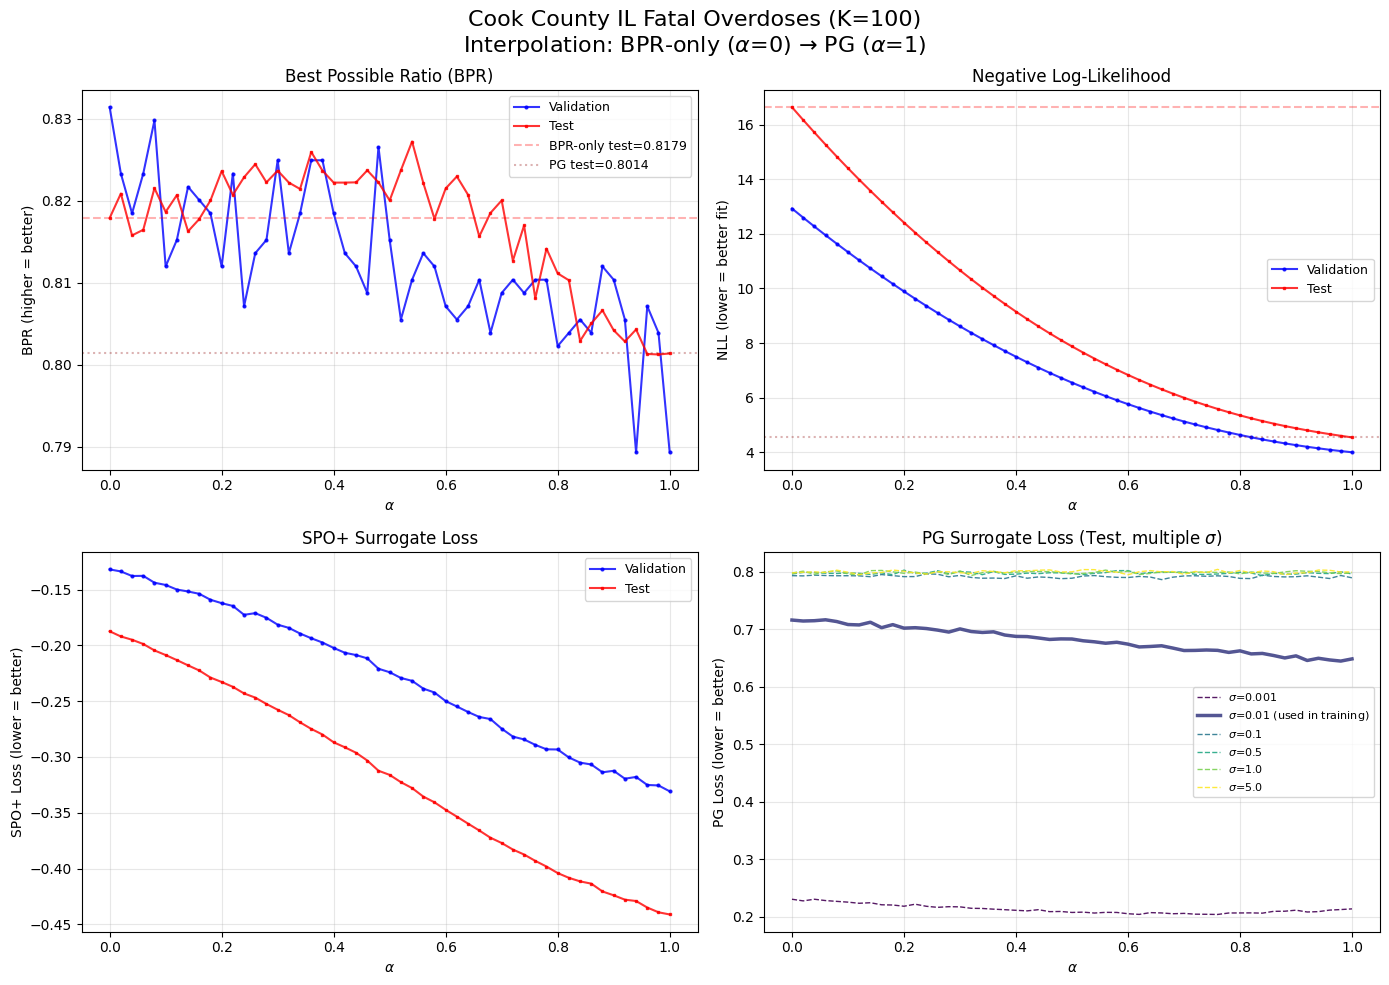


Plotting: cook / BPR_to_SPO
  Saved: interpolation_curves_cook_BPR_to_SPO.pdf


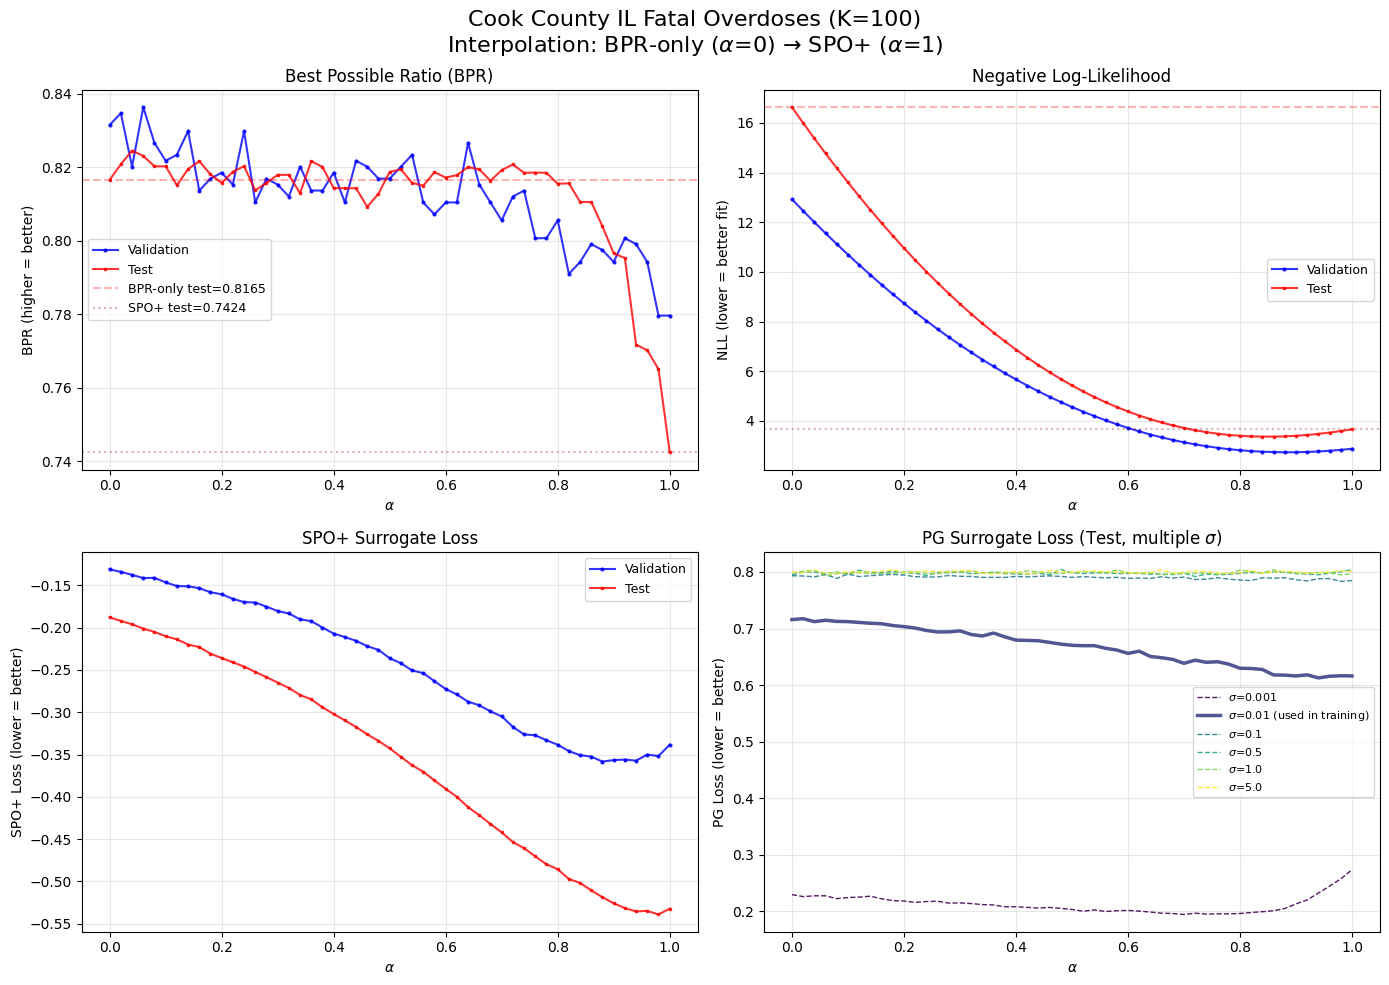


Plotting: MA / BPR_to_PG
  Saved: interpolation_curves_MA_BPR_to_PG.pdf


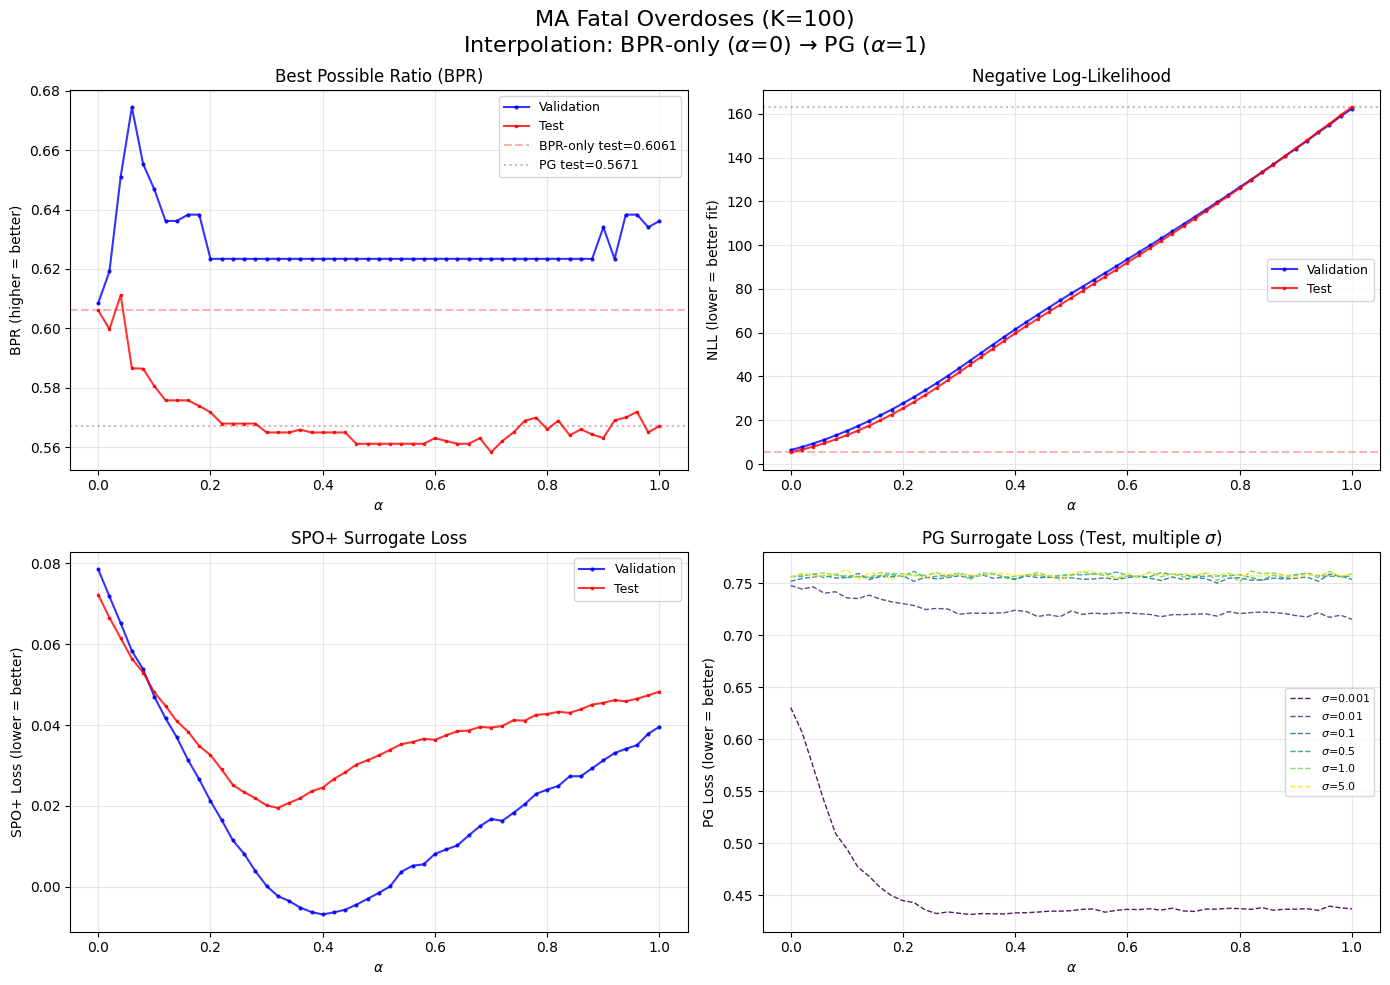


Plotting: MA / BPR_to_SPO
  Saved: interpolation_curves_MA_BPR_to_SPO.pdf


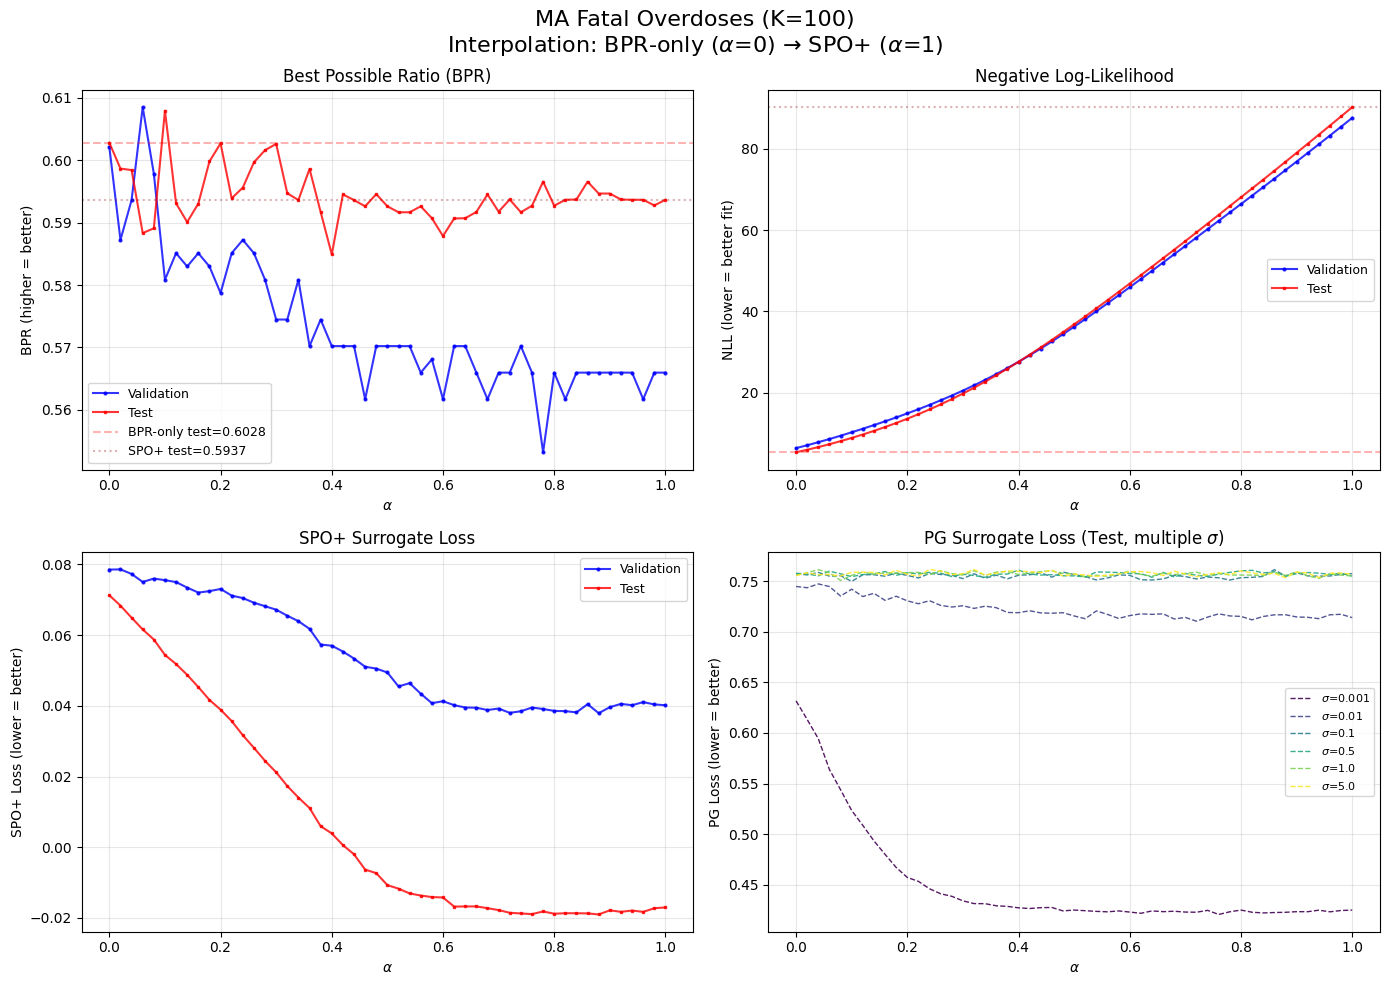


Plotting: asurv / BPR_to_PG
  Saved: interpolation_curves_asurv_BPR_to_PG.pdf


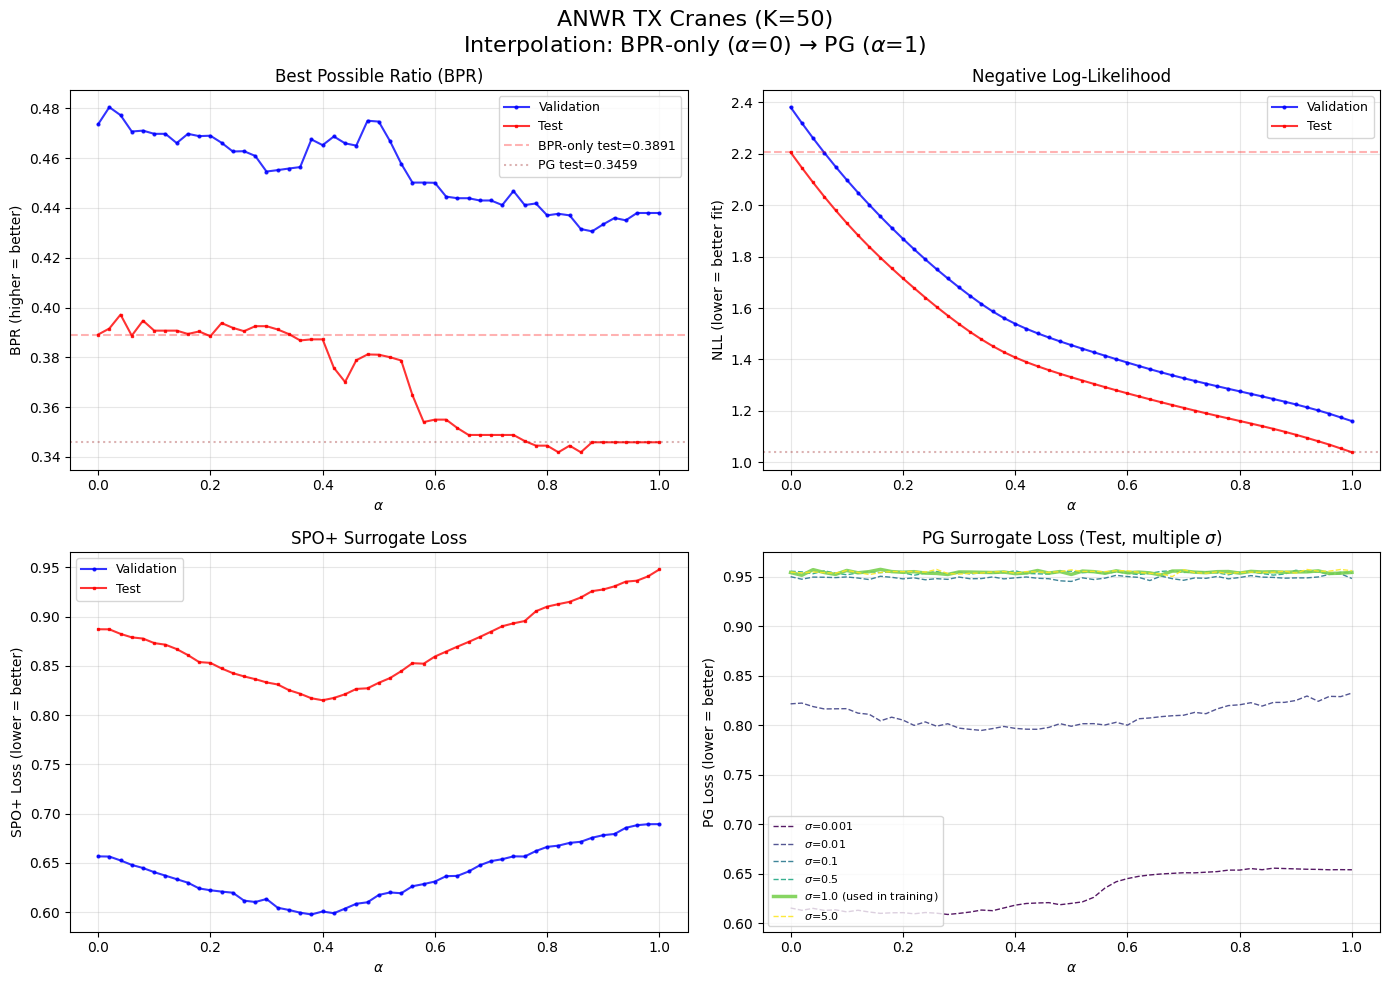


Plotting: asurv / BPR_to_SPO
  Saved: interpolation_curves_asurv_BPR_to_SPO.pdf


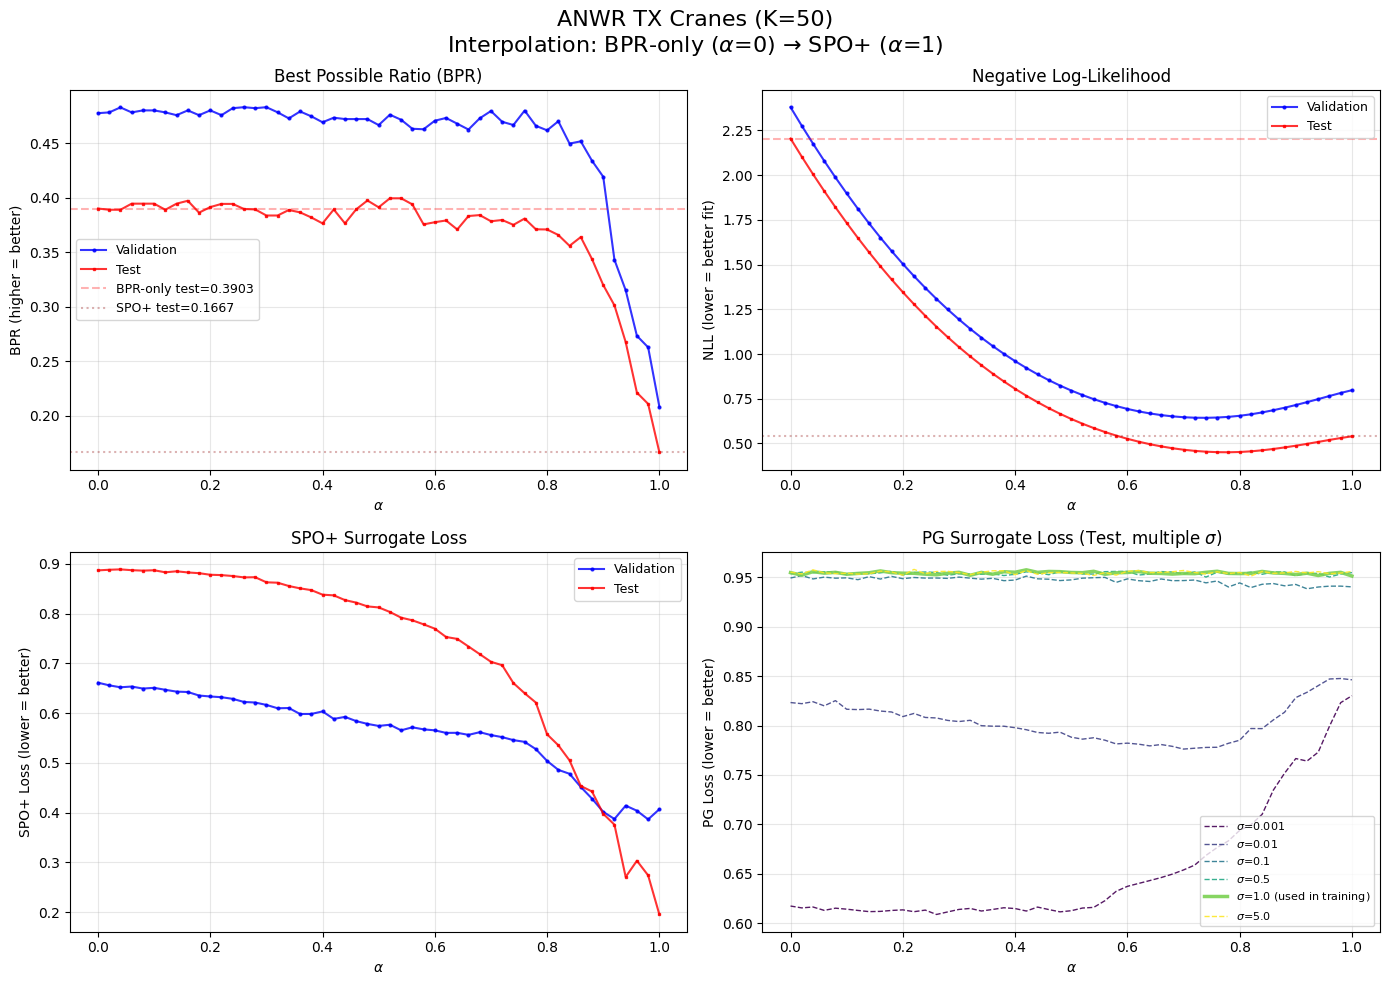

In [9]:
def plot_interpolation_curves(df, dataset_name, method_pair, K, pg_sigmas, pg_sigma_used=None, save=True):
    """Plot a 2x2 grid of interpolation curves.
    
    Top-left: BPR (val + test) vs alpha
    Top-right: NLL (val + test) vs alpha
    Bottom-left: SPO+ loss (val + test) vs alpha
    Bottom-right: PG loss at multiple sigmas (test) vs alpha
    """
    other_name = method_pair.split('_to_')[1]  # 'PG' or 'SPO'
    if other_name == 'SPO':
        other_name = 'SPO+'
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'{DATASET_CONFIGS[dataset_name]["title"]} (K={K})\n'
                 f'Interpolation: BPR-only ($\\alpha$=0) → {other_name} ($\\alpha$=1)',
                 fontsize=16)
    
    alpha = df['alpha']
    
    # --- Top-left: BPR ---
    ax = axes[0, 0]
    ax.plot(alpha, df['val_bpr'], 'b-o', markersize=2, label='Validation', alpha=0.8)
    ax.plot(alpha, df['test_bpr'], 'r-s', markersize=2, label='Test', alpha=0.8)
    ax.axhline(df['test_bpr'].iloc[0], color='r', linestyle='--', alpha=0.3, label=f'BPR-only test={df["test_bpr"].iloc[0]:.4f}')
    ax.axhline(df['test_bpr'].iloc[-1], color='darkred', linestyle=':', alpha=0.3, label=f'{other_name} test={df["test_bpr"].iloc[-1]:.4f}')
    ax.set_xlabel('$\\alpha$')
    ax.set_ylabel('BPR (higher = better)')
    ax.set_title('Best Possible Ratio (BPR)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # --- Top-right: NLL ---
    ax = axes[0, 1]
    ax.plot(alpha, df['val_nll'], 'b-o', markersize=2, label='Validation', alpha=0.8)
    ax.plot(alpha, df['test_nll'], 'r-s', markersize=2, label='Test', alpha=0.8)
    ax.axhline(df['test_nll'].iloc[0], color='r', linestyle='--', alpha=0.3)
    ax.axhline(df['test_nll'].iloc[-1], color='darkred', linestyle=':', alpha=0.3)
    ax.set_xlabel('$\\alpha$')
    ax.set_ylabel('NLL (lower = better fit)')
    ax.set_title('Negative Log-Likelihood')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # --- Bottom-left: SPO+ loss ---
    ax = axes[1, 0]
    ax.plot(alpha, df['val_spo_plus'], 'b-o', markersize=2, label='Validation', alpha=0.8)
    ax.plot(alpha, df['test_spo_plus'], 'r-s', markersize=2, label='Test', alpha=0.8)
    ax.set_xlabel('$\\alpha$')
    ax.set_ylabel('SPO+ Loss (lower = better)')
    ax.set_title('SPO+ Surrogate Loss')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # --- Bottom-right: PG loss at multiple sigmas ---
    ax = axes[1, 1]
    cmap = plt.cm.viridis
    for i, sigma in enumerate(pg_sigmas):
        color = cmap(i / max(len(pg_sigmas) - 1, 1))
        lw = 2.5 if (pg_sigma_used is not None and sigma == pg_sigma_used) else 1.0
        ls = '-' if (pg_sigma_used is not None and sigma == pg_sigma_used) else '--'
        label = f'$\\sigma$={sigma}'
        if pg_sigma_used is not None and sigma == pg_sigma_used:
            label += ' (used in training)'
        ax.plot(alpha, df[f'test_pg_sigma_{sigma}'], color=color, linewidth=lw,
                linestyle=ls, label=label, alpha=0.9)
    ax.set_xlabel('$\\alpha$')
    ax.set_ylabel('PG Loss (lower = better)')
    ax.set_title('PG Surrogate Loss (Test, multiple $\\sigma$)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    if save:
        fname = f'interpolation_curves_{dataset_name}_{method_pair}.pdf'
        plt.savefig(fname, dpi=600, bbox_inches='tight')
        print(f'  Saved: {fname}')
    plt.show()


# Generate plots for all datasets and method pairs
for (ds_name, method_pair), df in all_results.items():
    cfg = DATASET_CONFIGS[ds_name]
    print(f'\nPlotting: {ds_name} / {method_pair}')
    plot_interpolation_curves(df, ds_name, method_pair, cfg['K'], PG_SIGMAS,
                             pg_sigma_used=cfg['pg_sigma_used'])

## Plot 2: Side-by-Side BPR Comparison (BPR→PG vs BPR→SPO+ per dataset)

A cleaner view focusing just on decision quality (BPR) along both interpolation paths.

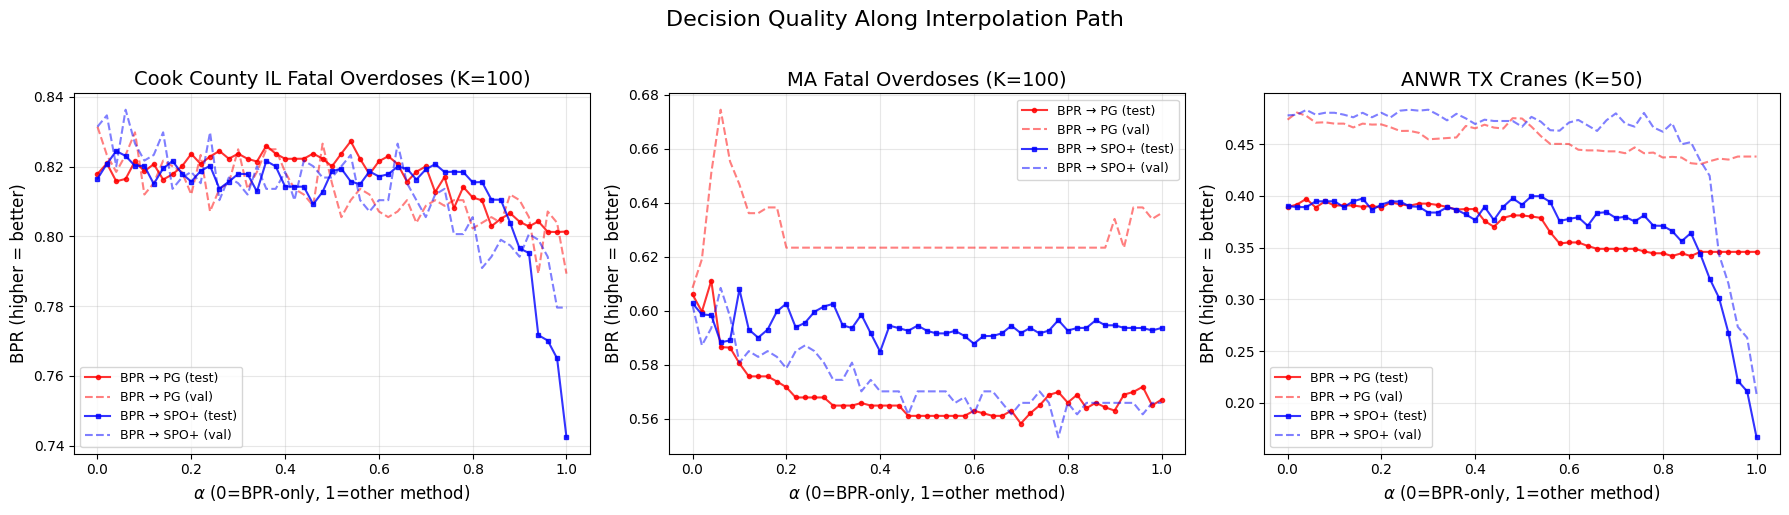

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax_idx, ds_name in enumerate(DATASET_CONFIGS.keys()):
    ax = axes[ax_idx]
    cfg = DATASET_CONFIGS[ds_name]
    
    df_pg = all_results.get((ds_name, 'BPR_to_PG'))
    df_spo = all_results.get((ds_name, 'BPR_to_SPO'))
    
    if df_pg is not None:
        ax.plot(df_pg['alpha'], df_pg['test_bpr'], 'r-o', markersize=3,
                label='BPR → PG (test)', alpha=0.8)
        ax.plot(df_pg['alpha'], df_pg['val_bpr'], 'r--', markersize=2,
                label='BPR → PG (val)', alpha=0.5)
    
    if df_spo is not None:
        ax.plot(df_spo['alpha'], df_spo['test_bpr'], 'b-s', markersize=3,
                label='BPR → SPO+ (test)', alpha=0.8)
        ax.plot(df_spo['alpha'], df_spo['val_bpr'], 'b--', markersize=2,
                label='BPR → SPO+ (val)', alpha=0.5)
    
    ax.set_xlabel('$\\alpha$ (0=BPR-only, 1=other method)', fontsize=12)
    ax.set_ylabel('BPR (higher = better)', fontsize=12)
    ax.set_title(f'{cfg["title"]} (K={cfg["K"]})', fontsize=14)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Decision Quality Along Interpolation Path', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('interpolation_bpr_comparison_all_datasets.pdf', dpi=600, bbox_inches='tight')
plt.show()

## Plot 3: PG Sigma Sensitivity at Endpoints

At the BPR-only solution ($\alpha=0$) and the PG solution ($\alpha=1$), how does PG loss vary with $\sigma$?  
This reveals whether the PG loss landscape is well-behaved at each solution.

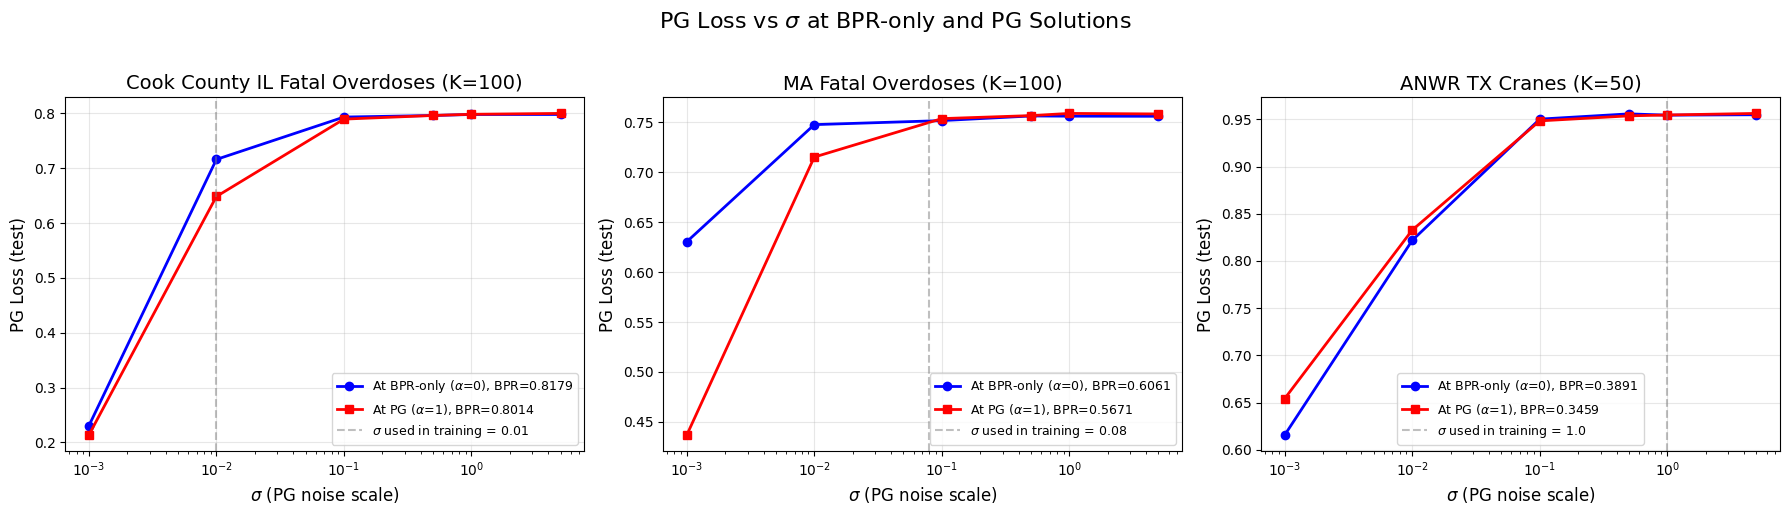

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax_idx, ds_name in enumerate(DATASET_CONFIGS.keys()):
    ax = axes[ax_idx]
    cfg = DATASET_CONFIGS[ds_name]
    
    df_pg = all_results.get((ds_name, 'BPR_to_PG'))
    if df_pg is None:
        continue
    
    # Extract PG loss at alpha=0 and alpha=1 for each sigma
    row_bpr = df_pg[df_pg['alpha'] == 0.0].iloc[0]
    row_pg = df_pg[df_pg['alpha'] == 1.0].iloc[0]
    
    pg_losses_at_bpr = [row_bpr[f'test_pg_sigma_{s}'] for s in PG_SIGMAS]
    pg_losses_at_pg = [row_pg[f'test_pg_sigma_{s}'] for s in PG_SIGMAS]
    
    ax.plot(PG_SIGMAS, pg_losses_at_bpr, 'b-o', markersize=6, linewidth=2,
            label=f'At BPR-only ($\\alpha$=0), BPR={row_bpr["test_bpr"]:.4f}')
    ax.plot(PG_SIGMAS, pg_losses_at_pg, 'r-s', markersize=6, linewidth=2,
            label=f'At PG ($\\alpha$=1), BPR={row_pg["test_bpr"]:.4f}')
    
    # Mark the sigma that was actually used in PG training
    ax.axvline(cfg['pg_sigma_used'], color='gray', linestyle='--', alpha=0.5,
               label=f'$\\sigma$ used in training = {cfg["pg_sigma_used"]}')
    
    ax.set_xlabel('$\\sigma$ (PG noise scale)', fontsize=12)
    ax.set_ylabel('PG Loss (test)', fontsize=12)
    ax.set_xscale('log')
    ax.set_title(f'{cfg["title"]} (K={cfg["K"]})', fontsize=14)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('PG Loss vs $\\sigma$ at BPR-only and PG Solutions', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('pg_sigma_sensitivity_endpoints.pdf', dpi=600, bbox_inches='tight')
plt.show()

## Plot 4: PG Loss Heatmap (alpha vs sigma)

A 2D heatmap showing PG loss as a function of both interpolation position and noise scale, for each dataset.

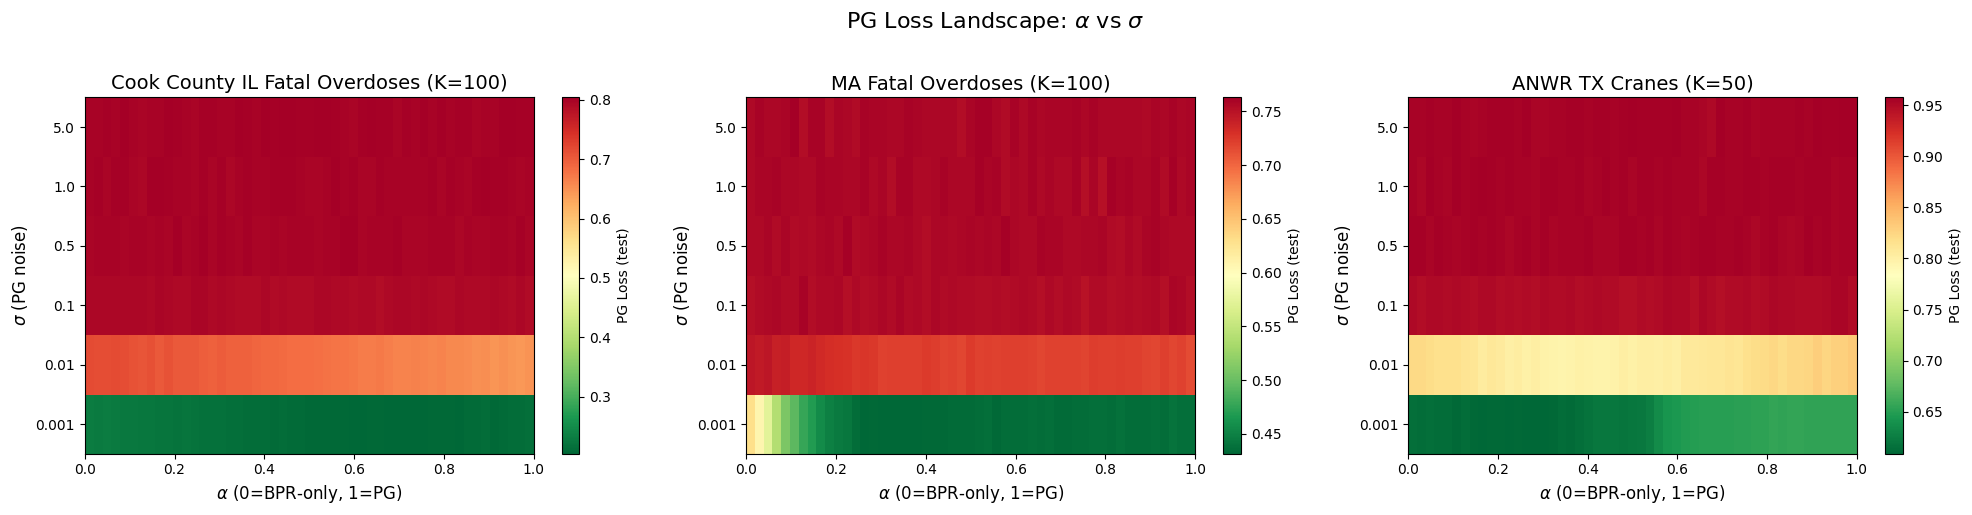

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax_idx, ds_name in enumerate(DATASET_CONFIGS.keys()):
    ax = axes[ax_idx]
    cfg = DATASET_CONFIGS[ds_name]
    
    df_pg = all_results.get((ds_name, 'BPR_to_PG'))
    if df_pg is None:
        continue
    
    # Build 2D array: rows=sigma, cols=alpha
    pg_matrix = np.zeros((len(PG_SIGMAS), len(df_pg)))
    for i, sigma in enumerate(PG_SIGMAS):
        pg_matrix[i, :] = df_pg[f'test_pg_sigma_{sigma}'].values
    
    im = ax.imshow(pg_matrix, aspect='auto', origin='lower',
                   extent=[0, 1, -0.5, len(PG_SIGMAS)-0.5],
                   cmap='RdYlGn_r')  # red=high loss, green=low loss
    ax.set_yticks(range(len(PG_SIGMAS)))
    ax.set_yticklabels([f'{s}' for s in PG_SIGMAS])
    ax.set_xlabel('$\\alpha$ (0=BPR-only, 1=PG)', fontsize=12)
    ax.set_ylabel('$\\sigma$ (PG noise)', fontsize=12)
    ax.set_title(f'{cfg["title"]} (K={cfg["K"]})', fontsize=14)
    plt.colorbar(im, ax=ax, label='PG Loss (test)')

plt.suptitle('PG Loss Landscape: $\\alpha$ vs $\\sigma$', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('pg_loss_heatmap_all_datasets.pdf', dpi=600, bbox_inches='tight')
plt.show()

## Plot 5: Normalized Regret (1-BPR) Along the Path

Regret = 1 - BPR, which is a more intuitive loss measure. If regret increases monotonically from BPR-only to PG/SPO+, the surrogate methods found genuinely worse solutions.

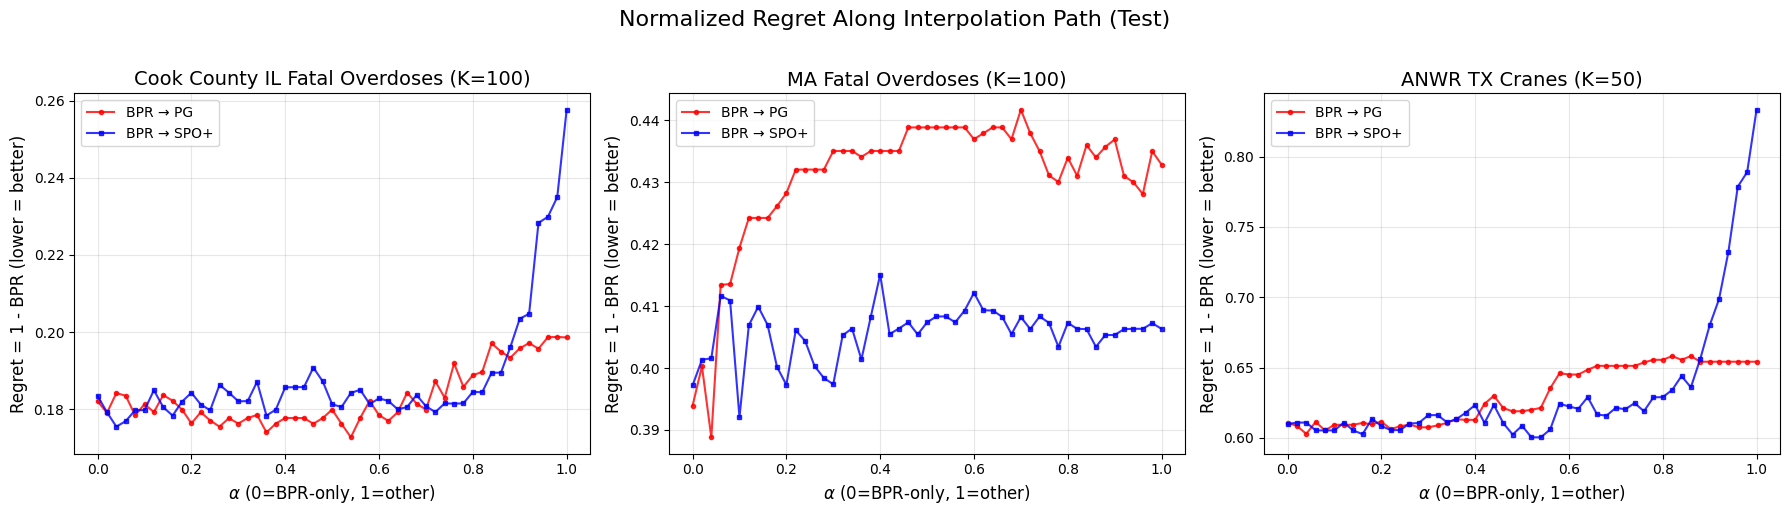

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax_idx, ds_name in enumerate(DATASET_CONFIGS.keys()):
    ax = axes[ax_idx]
    cfg = DATASET_CONFIGS[ds_name]
    
    df_pg = all_results.get((ds_name, 'BPR_to_PG'))
    df_spo = all_results.get((ds_name, 'BPR_to_SPO'))
    
    if df_pg is not None:
        regret_pg = 1.0 - df_pg['test_bpr']
        ax.plot(df_pg['alpha'], regret_pg, 'r-o', markersize=3,
                label=f'BPR → PG', alpha=0.8)
    
    if df_spo is not None:
        regret_spo = 1.0 - df_spo['test_bpr']
        ax.plot(df_spo['alpha'], regret_spo, 'b-s', markersize=3,
                label=f'BPR → SPO+', alpha=0.8)
    
    ax.set_xlabel('$\\alpha$ (0=BPR-only, 1=other)', fontsize=12)
    ax.set_ylabel('Regret = 1 - BPR (lower = better)', fontsize=12)
    ax.set_title(f'{cfg["title"]} (K={cfg["K"]})', fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Normalized Regret Along Interpolation Path (Test)', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('interpolation_regret_all_datasets.pdf', dpi=600, bbox_inches='tight')
plt.show()

## Plot 6: BPR vs NLL Tradeoff Along the Path

Parametric plot showing the BPR-NLL tradeoff as we interpolate. Each point is one alpha value.

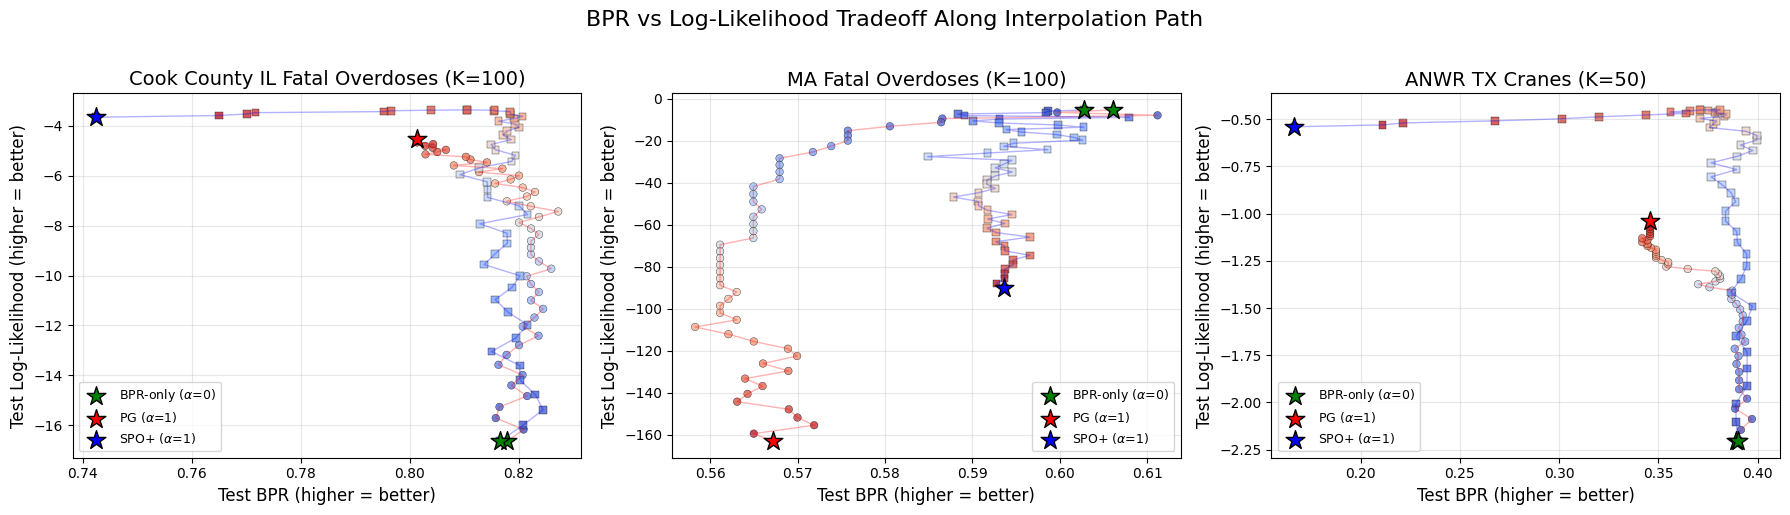

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax_idx, ds_name in enumerate(DATASET_CONFIGS.keys()):
    ax = axes[ax_idx]
    cfg = DATASET_CONFIGS[ds_name]
    
    for method_pair, color, marker in [('BPR_to_PG', 'red', 'o'), ('BPR_to_SPO', 'blue', 's')]:
        df = all_results.get((ds_name, method_pair))
        if df is None:
            continue
        
        other_name = 'PG' if 'PG' in method_pair else 'SPO+'
        
        # Color-code by alpha
        scatter = ax.scatter(df['test_bpr'], -df['test_nll'], c=df['alpha'],
                            cmap='coolwarm', marker=marker, s=30, alpha=0.8,
                            edgecolors='k', linewidths=0.3)
        
        # Mark endpoints
        ax.scatter(df['test_bpr'].iloc[0], -df['test_nll'].iloc[0],
                   color='green', marker='*', s=200, zorder=5, edgecolors='k',
                   label='BPR-only ($\\alpha$=0)')
        ax.scatter(df['test_bpr'].iloc[-1], -df['test_nll'].iloc[-1],
                   color=color, marker='*', s=200, zorder=5, edgecolors='k',
                   label=f'{other_name} ($\\alpha$=1)')
        
        # Connect with line
        ax.plot(df['test_bpr'], -df['test_nll'], color=color, alpha=0.3, linewidth=1)
    
    ax.set_xlabel('Test BPR (higher = better)', fontsize=12)
    ax.set_ylabel('Test Log-Likelihood (higher = better)', fontsize=12)
    ax.set_title(f'{cfg["title"]} (K={cfg["K"]})', fontsize=14)
    # Deduplicate legend
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('BPR vs Log-Likelihood Tradeoff Along Interpolation Path', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('interpolation_bpr_vs_nll_all_datasets.pdf', dpi=600, bbox_inches='tight')
plt.show()

## Summary Table

Quick numerical summary: does BPR decrease monotonically? Where is the best BPR along the path?

In [15]:
summary_rows = []

for (ds_name, method_pair), df in all_results.items():
    other_name = 'PG' if 'PG' in method_pair else 'SPO+'
    cfg = DATASET_CONFIGS[ds_name]
    
    bpr_at_0 = df['test_bpr'].iloc[0]
    bpr_at_1 = df['test_bpr'].iloc[-1]
    nll_at_0 = df['test_nll'].iloc[0]
    nll_at_1 = df['test_nll'].iloc[-1]
    
    best_bpr_idx = df['test_bpr'].idxmax()
    best_alpha = df.loc[best_bpr_idx, 'alpha']
    best_bpr = df.loc[best_bpr_idx, 'test_bpr']
    
    # Check monotonicity: is BPR strictly decreasing along the path?
    bpr_diffs = df['test_bpr'].diff().dropna()
    is_monotone_decreasing = (bpr_diffs <= 0).all()
    # More lenient check: is the best BPR at or very near alpha=0?
    best_at_endpoint = best_alpha <= 0.04
    
    summary_rows.append({
        'Dataset': ds_name,
        'K': cfg['K'],
        'Method Pair': f'BPR → {other_name}',
        'BPR at α=0 (BPR-only)': f'{bpr_at_0:.4f}',
        'BPR at α=1 (other)': f'{bpr_at_1:.4f}',
        'BPR drop': f'{bpr_at_0 - bpr_at_1:.4f}',
        'NLL at α=0': f'{nll_at_0:.2f}',
        'NLL at α=1': f'{nll_at_1:.2f}',
        'Best α for BPR': f'{best_alpha:.2f}',
        'Best test BPR': f'{best_bpr:.4f}',
        'Monotone ↓?': '✓' if is_monotone_decreasing else '✗',
        'Best at BPR-only?': '✓' if best_at_endpoint else '✗',
    })

summary_df = pd.DataFrame(summary_rows)
print('\n' + '='*100)
print('INTERPOLATION SUMMARY')
print('='*100)
print()
print('Key question: Is the BPR-only solution genuinely better, or did PG/SPO+ get stuck in a local minimum?')
print()
print('  - "Monotone ↓" = BPR decreases at every step from BPR-only to other → BPR-only found a superior solution')
print('  - "Best at BPR-only" = The peak BPR along the path is at or near α=0')
print('  - If best α is NOT 0 → there may be a better solution between the two endpoints (local min issue)') 
print()
display(summary_df)


INTERPOLATION SUMMARY

Key question: Is the BPR-only solution genuinely better, or did PG/SPO+ get stuck in a local minimum?

  - "Monotone ↓" = BPR decreases at every step from BPR-only to other → BPR-only found a superior solution
  - "Best at BPR-only" = The peak BPR along the path is at or near α=0
  - If best α is NOT 0 → there may be a better solution between the two endpoints (local min issue)



,Dataset,K,Method Pair,BPR at α=0 (BPR-only),BPR at α=1 (other),BPR drop,NLL at α=0,NLL at α=1,Best α for BPR,Best test BPR,Monotone ↓?,Best at BPR-only?
0,cook,100,BPR → PG,0.8179,0.8014,0.0165,16.63,4.54,0.54,0.8272,✗,✗
1,cook,100,BPR → SPO+,0.8165,0.7424,0.0741,16.63,3.66,0.04,0.8245,✗,✓
2,MA,100,BPR → PG,0.6061,0.5671,0.0390,5.37,163.09,0.04,0.6112,✗,✓
3,MA,100,BPR → SPO+,0.6028,0.5937,0.0091,5.37,90.26,0.10,0.6080,✗,✗
4,asurv,50,BPR → PG,0.3891,0.3459,0.0433,2.20,1.04,0.04,0.3972,✗,✓
5,asurv,50,BPR → SPO+,0.3903,0.1667,0.2235,2.20,0.54,0.52,0.3996,✗,✗


## Plot 7: Does PG Loss Agree with True Decision Quality?

Overlay PG loss and regret (1-BPR) on the same plot to see if the PG surrogate is well-correlated with actual decision quality. If PG loss has a minimum at a different location than regret, the surrogate is misleading the optimizer.

KeyError: 'test_pg_sigma_0.08'

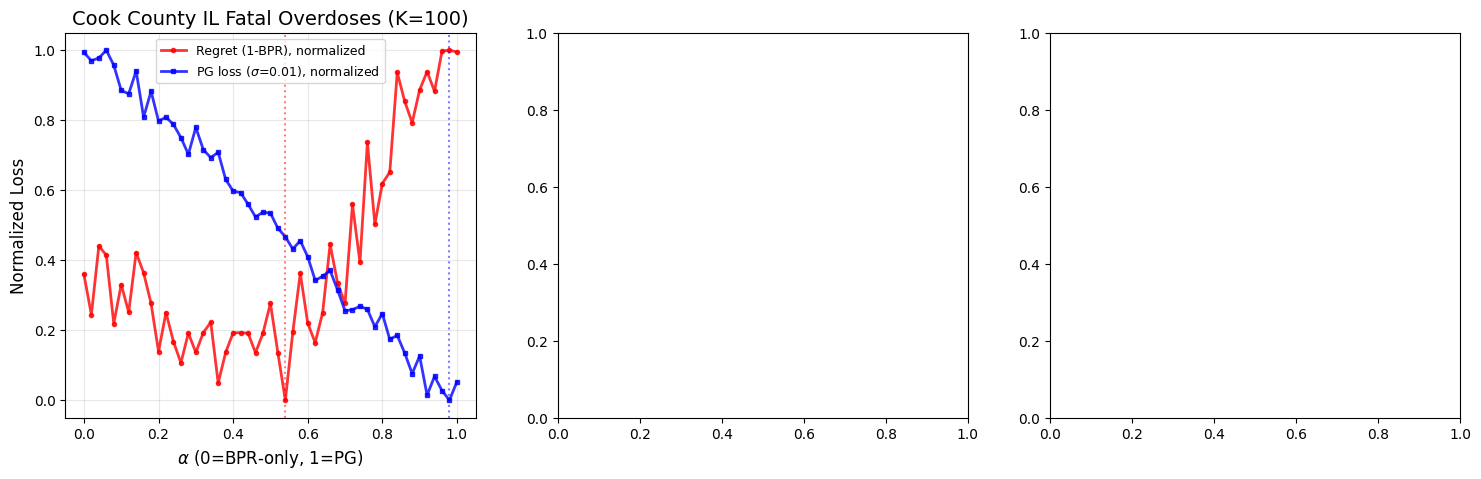

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax_idx, ds_name in enumerate(DATASET_CONFIGS.keys()):
    ax = axes[ax_idx]
    cfg = DATASET_CONFIGS[ds_name]
    
    df_pg = all_results.get((ds_name, 'BPR_to_PG'))
    if df_pg is None:
        continue
    
    sigma_used = cfg['pg_sigma_used']
    regret = 1.0 - df_pg['test_bpr']
    pg_loss = df_pg[f'test_pg_sigma_{sigma_used}']
    
    # Normalize both to [0, 1] for comparison
    regret_norm = (regret - regret.min()) / (regret.max() - regret.min() + 1e-10)
    pg_norm = (pg_loss - pg_loss.min()) / (pg_loss.max() - pg_loss.min() + 1e-10)
    
    ax.plot(df_pg['alpha'], regret_norm, 'r-o', markersize=3, linewidth=2,
            label='Regret (1-BPR), normalized', alpha=0.8)
    ax.plot(df_pg['alpha'], pg_norm, 'b-s', markersize=3, linewidth=2,
            label=f'PG loss ($\\sigma$={sigma_used}), normalized', alpha=0.8)
    
    # Mark minima
    regret_min_idx = regret_norm.idxmin()
    pg_min_idx = pg_norm.idxmin()
    ax.axvline(df_pg.loc[regret_min_idx, 'alpha'], color='r', linestyle=':', alpha=0.5)
    ax.axvline(df_pg.loc[pg_min_idx, 'alpha'], color='b', linestyle=':', alpha=0.5)
    
    ax.set_xlabel('$\\alpha$ (0=BPR-only, 1=PG)', fontsize=12)
    ax.set_ylabel('Normalized Loss', fontsize=12)
    ax.set_title(f'{cfg["title"]} (K={cfg["K"]})', fontsize=14)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('PG Surrogate vs True Regret Along Interpolation Path', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('pg_vs_regret_alignment.pdf', dpi=600, bbox_inches='tight')
plt.show()

## Extended PG Sigma Sweep at Both Endpoints

More detailed exploration: compute PG loss over a finer grid of sigma values at the BPR-only and PG solutions. This helps diagnose whether the sigma hyperparameter was poorly tuned.

In [ ]:
FINE_SIGMAS = np.logspace(-4, 1, 30)  # 0.0001 to 10, 30 points

sigma_sweep_results = {}

for ds_name, cfg in DATASET_CONFIGS.items():
    print(f'\nSigma sweep for {ds_name}...')
    
    data = load_data(cfg['data_dir'], bird=cfg['bird'])
    val_data = tuple(x.to(device) for x in data['val'])
    test_data = tuple(x.to(device) for x in data['test'])
    
    num_locations = data['train'][0].shape[1]
    num_fixed_effects = data['train'][0].shape[2]
    
    model_bpr = load_model(cfg['bpr_only_path'], num_locations, num_fixed_effects, device)
    params_bpr = model_bpr.params_to_single_tensor().detach().clone()
    
    model_pg = load_model(cfg['pg_path'], num_locations, num_fixed_effects, device)
    params_pg = model_pg.params_to_single_tensor().detach().clone()
    
    test_X, test_time, test_y = test_data
    val_X, val_time, val_y = val_data
    
    # Compute ratio_rating at both endpoints
    rr_bpr_test = compute_ratio_rating(model_bpr, params_bpr, test_X, test_time, NUM_RATIO_SAMPLES)
    rr_pg_test = compute_ratio_rating(model_bpr, params_pg, test_X, test_time, NUM_RATIO_SAMPLES)
    rr_bpr_val = compute_ratio_rating(model_bpr, params_bpr, val_X, val_time, NUM_RATIO_SAMPLES)
    rr_pg_val = compute_ratio_rating(model_bpr, params_pg, val_X, val_time, NUM_RATIO_SAMPLES)
    
    records = []
    for sigma in FINE_SIGMAS:
        pg_bpr_test = compute_pg_loss(rr_bpr_test, test_y, cfg['K'], sigma, PG_PERTURBATION_SAMPLES)
        pg_pg_test = compute_pg_loss(rr_pg_test, test_y, cfg['K'], sigma, PG_PERTURBATION_SAMPLES)
        pg_bpr_val = compute_pg_loss(rr_bpr_val, val_y, cfg['K'], sigma, PG_PERTURBATION_SAMPLES)
        pg_pg_val = compute_pg_loss(rr_pg_val, val_y, cfg['K'], sigma, PG_PERTURBATION_SAMPLES)
        
        records.append({
            'sigma': sigma,
            'pg_loss_at_bpr_test': pg_bpr_test,
            'pg_loss_at_pg_test': pg_pg_test,
            'pg_loss_at_bpr_val': pg_bpr_val,
            'pg_loss_at_pg_val': pg_pg_val,
        })
    
    sigma_sweep_results[ds_name] = pd.DataFrame(records)
    print(f'  Done ({len(FINE_SIGMAS)} sigma values)')

print('\nAll sigma sweeps complete!')

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax_idx, ds_name in enumerate(DATASET_CONFIGS.keys()):
    cfg = DATASET_CONFIGS[ds_name]
    df_sigma = sigma_sweep_results[ds_name]
    
    # Top row: test set
    ax = axes[0, ax_idx]
    ax.plot(df_sigma['sigma'], df_sigma['pg_loss_at_bpr_test'], 'b-o', markersize=3,
            linewidth=2, label='At BPR-only solution', alpha=0.8)
    ax.plot(df_sigma['sigma'], df_sigma['pg_loss_at_pg_test'], 'r-s', markersize=3,
            linewidth=2, label='At PG solution', alpha=0.8)
    ax.axvline(cfg['pg_sigma_used'], color='gray', linestyle='--', alpha=0.7,
               label=f'Training $\\sigma$={cfg["pg_sigma_used"]}')
    ax.set_xscale('log')
    ax.set_xlabel('$\\sigma$')
    ax.set_ylabel('PG Loss (test)')
    ax.set_title(f'{cfg["title"]} — Test')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # Bottom row: validation set
    ax = axes[1, ax_idx]
    ax.plot(df_sigma['sigma'], df_sigma['pg_loss_at_bpr_val'], 'b-o', markersize=3,
            linewidth=2, label='At BPR-only solution', alpha=0.8)
    ax.plot(df_sigma['sigma'], df_sigma['pg_loss_at_pg_val'], 'r-s', markersize=3,
            linewidth=2, label='At PG solution', alpha=0.8)
    ax.axvline(cfg['pg_sigma_used'], color='gray', linestyle='--', alpha=0.7,
               label=f'Training $\\sigma$={cfg["pg_sigma_used"]}')
    ax.set_xscale('log')
    ax.set_xlabel('$\\sigma$')
    ax.set_ylabel('PG Loss (val)')
    ax.set_title(f'{cfg["title"]} — Validation')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Fine-Grained PG Loss vs $\\sigma$ at BPR-only and PG Solutions', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('pg_sigma_fine_sweep.pdf', dpi=600, bbox_inches='tight')
plt.show()

## Key Takeaways

1. **Monotonic BPR decrease?** If BPR decreases monotonically from BPR-only to PG/SPO+, then the BPR-only method genuinely found a superior solution — the surrogate methods converged to an inferior point on the loss surface.

2. **Non-monotonic BPR?** If BPR first increases then decreases (or vice versa), the path between solutions passes through regions of varying quality, suggesting the problem landscape is complex and the surrogate methods may have gotten stuck in a local minimum.

3. **PG loss alignment:** If the PG surrogate loss doesn't correlate well with true regret (Plot 7), the PG gradient signal may be misleading the optimizer — even with the correct hyperparameters.

4. **Sigma sensitivity:** If PG loss changes dramatically with sigma (Plots 3, 4, and the fine sweep), the PG method is sensitive to this hyperparameter. If the BPR-only solution has lower PG loss than the PG solution across most sigma values, the problem is not just hyperparameter tuning — it's a fundamental limitation of how PG optimizes.